# Part B — 06 Final Model Evaluation and Business Interpretation

The tuned Random Forest was selected as the final model.

The model is retrained using patents from 2021–2023 and evaluated on
the previously untouched 2024 patent data.

The 2024 data is used only once for final model evaluation.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

ROOT = Path.cwd().parent

PROCESSED_DIR = ROOT / "Data" / "processed"
TABLES_DIR = ROOT / "Outputs" / "tables"

DATA_PATH = (
    PROCESSED_DIR /
    "01_part_b_target_dataset.parquet"
)

df = pd.read_parquet(DATA_PATH)

print("Rows:", f"{len(df):,}")
print("Columns:", df.shape[1])

Rows: 49,556
Columns: 26


In [2]:
numeric_features = [
    "inventor_count",
    "assignee_count",
    "cpc_count",
    "backward_citation_count",
    "title_word_count",
    "abstract_word_count",
    "claims_text_length",
    "claims_word_count",
    "filing_to_grant_days"
]

categorical_features = [
    "cpc_group",
    "assignee_country"
]

feature_columns = (
    numeric_features +
    categorical_features
)

X = df[feature_columns].copy()
y = df["high_impact"].copy()

In [3]:
development_mask = df["grant_year"].isin(
    [2021, 2022, 2023]
)

test_mask = df["grant_year"] == 2024

X_development = X.loc[
    development_mask
].copy()

y_development = y.loc[
    development_mask
].copy()

X_test = X.loc[
    test_mask
].copy()

y_test = y.loc[
    test_mask
].copy()

print("Development set:", X_development.shape)
print("Final test set:", X_test.shape)

Development set: (44062, 11)
Final test set: (5494, 11)


In [4]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [5]:
final_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=20,
                min_samples_split=10,
                min_samples_leaf=4,
                max_features="log2",
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [6]:
final_model.fit(
    X_development,
    y_development
)

print(
    "Final model trained on 2021–2023."
)

Final model trained on 2021–2023.


In [7]:
test_predictions = final_model.predict(
    X_test
)

test_probabilities = (
    final_model.predict_proba(
        X_test
    )[:, 1]
)

print("2024 predictions created.")

2024 predictions created.


In [8]:
final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "PR_AUC"
    ],

    "Score": [
        accuracy_score(
            y_test,
            test_predictions
        ),

        precision_score(
            y_test,
            test_predictions
        ),

        recall_score(
            y_test,
            test_predictions
        ),

        f1_score(
            y_test,
            test_predictions
        ),

        roc_auc_score(
            y_test,
            test_probabilities
        ),

        average_precision_score(
            y_test,
            test_probabilities
        )
    ]
})

final_results.round(3)

,Metric,Score
0,Accuracy,0.628
1,Precision,0.258
2,Recall,0.598
3,F1,0.360
4,ROC_AUC,0.666
5,PR_AUC,0.299


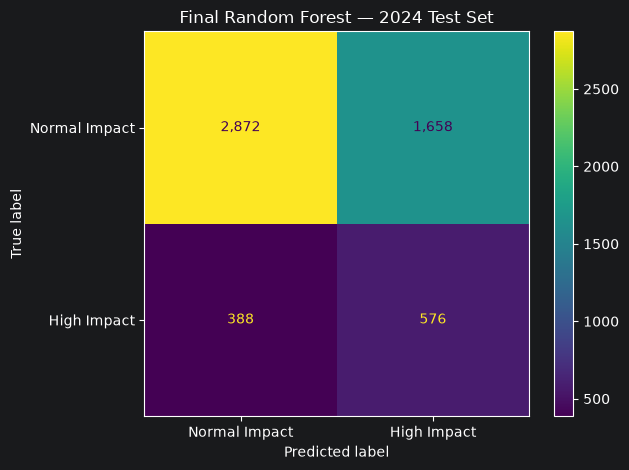

In [9]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal Impact",
        "High Impact"
    ]
)

disp.plot(
    values_format=","
)

plt.title(
    "Final Random Forest — 2024 Test Set"
)

plt.tight_layout()
plt.show()

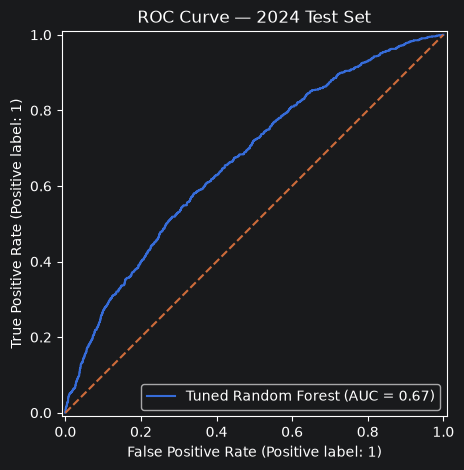

In [10]:
RocCurveDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="Tuned Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title(
    "ROC Curve — 2024 Test Set"
)

plt.tight_layout()
plt.show()

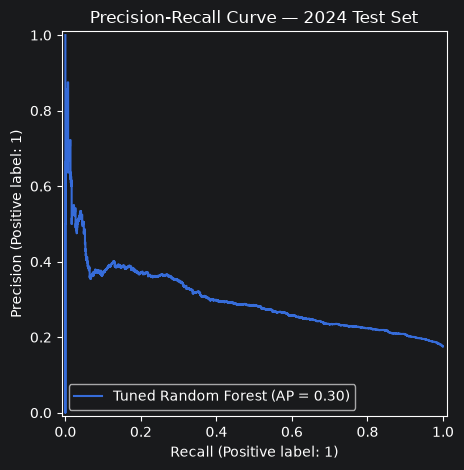

In [11]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    test_probabilities,
    name="Tuned Random Forest"
)

plt.title(
    "Precision-Recall Curve — 2024 Test Set"
)

plt.tight_layout()
plt.show()

In [12]:
final_results.to_csv(
    TABLES_DIR /
    "part_b_final_test_results.csv",
    index=False
)

print("Final test results saved.")

Final test results saved.


In [13]:
from sklearn.inspection import permutation_importance

In [14]:
permutation_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": permutation_result.importances_mean,
    "Std": permutation_result.importances_std
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

importance_df.round(4)

,Feature,Importance,Std
0,assignee_country,0.0674,0.0074
1,backward_citation_count,0.0365,0.0060
2,filing_to_grant_days,0.0181,0.0026
3,cpc_count,0.0113,0.0033
4,claims_word_count,0.0097,0.0040
5,claims_text_length,0.0044,0.0024
6,inventor_count,0.0027,0.0017
7,abstract_word_count,0.0015,0.0010
8,cpc_group,0.0014,0.0017
9,title_word_count,-0.0001,0.0009


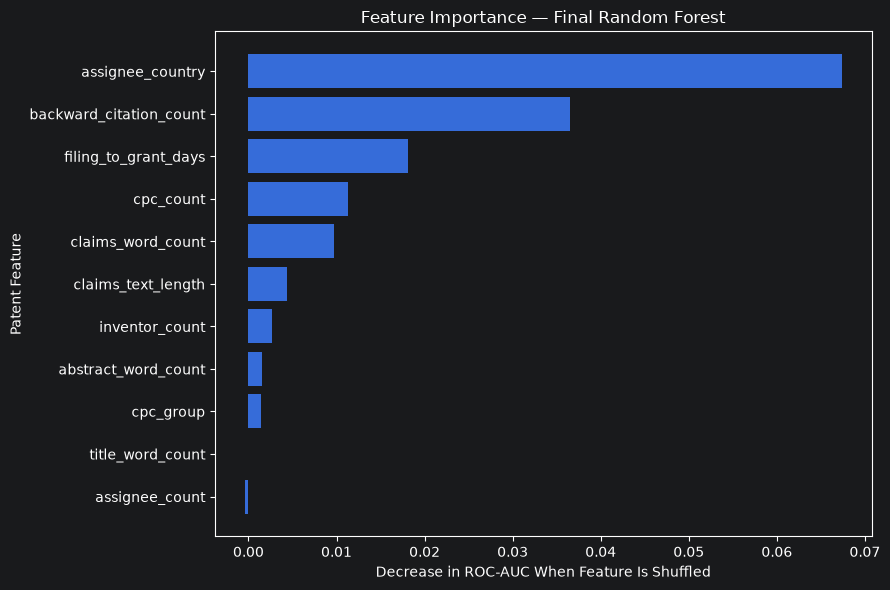

In [15]:
plot_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_df["Feature"],
    plot_df["Importance"]
)

plt.xlabel(
    "Decrease in ROC-AUC When Feature Is Shuffled"
)

plt.ylabel("Patent Feature")

plt.title(
    "Feature Importance — Final Random Forest"
)

plt.tight_layout()
plt.show()

In [16]:
importance_df.to_csv(
    TABLES_DIR /
    "part_b_feature_importance.csv",
    index=False
)

print(
    "Feature importance saved."
)

Feature importance saved.


## Final Model Performance

The tuned Random Forest achieved a ROC-AUC of 0.666 on the previously
unseen 2024 patent data.

The model identified approximately 60% of the actual high-impact patents,
with a recall of 0.598.

Precision was 0.258, indicating that not every patent identified as
high impact ultimately reached the high-impact threshold.

The results therefore suggest that patent metadata provides useful but
limited early signals of future patent impact. The model is better suited
as a screening and prioritization tool rather than as an automated
decision-making system.

In [17]:
test_results_df = df.loc[
    test_mask,
    [
        "publication_number",
        "primary_assignee",
        "assignee_country",
        "cpc_group",
        "forward_citations_24m",
        "high_impact"
    ]
].copy()

test_results_df[
    "predicted_impact_probability"
] = test_probabilities

test_results_df[
    "predicted_high_impact"
] = test_predictions

top_predicted_patents = (
    test_results_df
    .sort_values(
        "predicted_impact_probability",
        ascending=False
    )
    .head(20)
)

top_predicted_patents

,publication_number,primary_assignee,assignee_country,cpc_group,forward_citations_24m,high_impact,predicted_impact_probability,predicted_high_impact
47680,US-11922728-B1,AMAZON TECH INC,US,G06N3,1,0,0.784853,1
47788,US-11927925-B2,Johnson Controls Tyco IP Holdings LLP,US,G06N3,3,1,0.783294,1
49013,US-11948563-B1,META PLATFORMS INC,US,G06N3,17,1,0.780280,1
46266,US-11896432-B2,VEKTOR MEDICAL INC,US,G06N3,3,1,0.779259,1
46865,US-11907832-B2,LIGHTELLIGENCE INC,US,G06N3,3,1,0.777353,1
49141,US-11954063-B2,INTEL CORP,US,G06N3,2,1,0.776598,1
44206,US-11857273-B2,GLOBUS MEDICAL INC,US,G06N3,4,1,0.776194,1
45567,US-11886318-B1,VIGNET INC,US,G06N3,3,1,0.767208,1
47258,US-11915214-B1,PNC FINANCIAL SERVICES GROUP,US,G06N20,1,0,0.763591,1
45224,US-11875896-B2,EMED LABS LLC,US,G06N3,1,0,0.761393,1


In [18]:
top_predicted_patents.to_csv(
    TABLES_DIR /
    "part_b_top_predicted_patents.csv",
    index=False
)

print(
    "Top predicted patents saved."
)

Top predicted patents saved.
